# Tri-Modal Spatial GNN for Domain Identification (Improved Run 2)
### Self-Supervised Spatial Graph Learning on 10x Genomics Visium Mouse Brain (2,688 spots)

---

## What this notebook does

Trains a self-supervised graph neural network that fuses gene expression, multi-scale histology
morphology (DINOv2), and spatial topology to identify tissue domains in spatial transcriptomics data.

## Improvements over the corrected Run 2 notebook

1. **Clean negative sampling.** `spatial_infonce` now builds an adjacency set and guarantees negatives
   are never true spatial neighbors. The previous version used random permutation, which could sample
   actual positive pairs as negatives.

2. **Channel-wise gated fusion.** The old scalar gate learned to clamp down to ~0.28, suppressing most
   morphology. The new channel-wise gate lets each latent dimension independently decide how much
   morphology to use, with a learned value-projection and LayerNorm.

3. **Residual GATv2 encoder.** Skip connections across GAT layers prevent over-smoothing and stabilize
   gradient flow. Dropout regularizes the message-passing layers.

4. **Learning rate scheduling.** Cosine annealing LR with linear warmup replaces the constant 1e-3.
   Gradient clipping (max_norm=1.0) prevents attention/gate parameter instability.

5. **Exact cosine tau annealing.** Fixed the formula to (epoch-1)/(total_epochs-1) so temperature
   reaches tau_min precisely on the final epoch.

6. **Principled multi-scale fusion.** Standardize, weight, concatenate, then jointly PCA -- a single
   coordinate system built from both scales, not a blend of two independent PCA spaces.

7. **Individual component ablation.** Each improvement is tested in isolation so we can attribute
   gains to specific components rather than a bundled all-or-nothing comparison.

## What this notebook does NOT claim

- No comparison to published baselines (STAGATE, GraphST, conST, SpaGCN) -- this is an internal
  ablation study comparing variants of our own architecture.
- Reference labels (`adata.obs["cluster"]`) are squidpy's Leiden clustering, not expert-annotated
  anatomy. Metrics measure agreement with that reference, not recovery of true tissue layers.
- The 0.70/0.30 multi-scale weighting is a heuristic, not a tuned hyperparameter.

## Runtime note

N_SEEDS x N_VARIANTS x TOTAL_EPOCHS forward passes. On CPU this is slow. Reduce N_SEEDS or
TOTAL_EPOCHS for a quick smoke test; use GPU (Kaggle/Colab) for real numbers.

## Formulation

**Fusion (channel-wise gated modulation, not cross-attention):**

$$g = \sigma\left(W_g\,[Z_{\text{gene}} \| Z_{\text{morph}}] + b_g\right) \in \mathbb{R}^d$$

$$Z_{\text{fused}} = \text{LayerNorm}\left(Z_{\text{gene}} + g \odot \text{GELU}(W_m\,Z_{\text{morph}})\right)$$

Each latent channel independently decides how much morphology to incorporate.
This is a gated residual modulation -- there is no attention distribution.

**Loss:**

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{recon}}^{\text{gene}} + 0.5 \cdot \mathcal{L}_{\text{InfoNCE}}^{\text{spatial}}(\tau(t))$$

$$\mathcal{L}_{\text{InfoNCE}}(\tau) = -\log \frac{\exp(\text{sim}(z_i, z_j)/\tau)}{\exp(\text{sim}(z_i, z_j)/\tau) + \sum_{k=1}^{N_{\text{neg}}} \exp(\text{sim}(z_i, z_{k}^{\text{neg}})/\tau)}$$

Negatives are sampled from non-neighbor nodes only (true-positive exclusion).

**Temperature schedule (exact endpoints):**

$$\tau(t) = \tau_{\min} + \frac{1}{2}(\tau_{\max} - \tau_{\min})\left(1 + \cos\left(\frac{\pi(t-1)}{T-1}\right)\right)$$

## Step 1: Environment Setup

In [7]:
!pip install -q scanpy squidpy torch-geometric torchvision seaborn

import os
import sys
import random
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv
from torchvision import transforms
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    silhouette_samples,
)
from scipy.optimize import linear_sum_assignment
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# Hyperparameters -- adjust these for quick tests vs full runs
# ---------------------------------------------------------------------------
BASE_SEED = 42
N_SEEDS = 5              # >=3 recommended; 5 for publication-level confidence
TOTAL_EPOCHS = 200       # increased from 150 to allow cosine LR to converge
WARMUP_EPOCHS = 10       # linear LR warmup
LATENT_DIM = 64
N_NEIGHBORS = 6          # spatial graph k-NN
EDGE_DROP_P = 0.05       # edge perturbation probability
TAU_MAX = 0.25
TAU_MIN = 0.15
N_NEG = 16               # number of negative samples per edge
LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
LOCAL_WEIGHT = 0.70      # heuristic, not tuned
CONTEXT_WEIGHT = 0.30

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(BASE_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device} | PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")

OUT_DIR = "./output"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Output directory: '{OUT_DIR}'")

Device: cuda | PyTorch: 2.10.0+cu128 | CUDA: True
Output directory: './output'


## Step 2: Dataset Loading and Quality Control

Loads 10x Visium Mouse Brain Sagittal Anterior (2,688 spots).

**Important:** `adata.obs["cluster"]` is squidpy's own Leiden clustering of this dataset,
used as a fixed reference label for comparing model variants against each other.
It is NOT expert-annotated anatomical ground truth.

In [8]:
def load_visium_data():
    local_candidates = [
        "./visium_hne_adata.h5ad",
        "./data/anndata/visium_hne_adata.h5ad",
        "/kaggle/input/visium-mouse-brain/visium_hne_adata.h5ad",
    ]
    for path in local_candidates:
        if os.path.exists(path):
            print(f"Loading local dataset from: {path}")
            return sc.read_h5ad(path)
    print("Fetching dataset online via squidpy...")
    return sq.datasets.visium_hne_adata()

adata = load_visium_data()
adata.var_names_make_unique()

if "in_tissue" in adata.obs:
    adata = adata[adata.obs["in_tissue"] == 1].copy()

print(f"Raw dataset shape: {adata.n_obs} spots x {adata.n_vars} genes")

# Quality control
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

adata = adata[
    (adata.obs["total_counts"] > 500)
    & (adata.obs["n_genes_by_counts"] > 300)
    & (adata.obs["pct_counts_mt"] < 20)
].copy()

# Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# HVG selection and PCA
sc.pp.highly_variable_genes(adata, n_top_genes=3000, subset=True, flavor="seurat")
sc.pp.pca(adata, n_comps=50)
X_pca = np.ascontiguousarray(adata.obsm['X_pca'].copy())

print(f"Preprocessed: {adata.n_obs} spots x {X_pca.shape[1]} PCA components")
print("NOTE: Reference labels (adata.obs['cluster']) are squidpy's Leiden clustering,")
print("      not expert-annotated anatomy. Metrics below measure agreement with that reference.")

Loading local dataset from: ./data/anndata/visium_hne_adata.h5ad
Raw dataset shape: 2688 spots x 18078 genes
Preprocessed: 2688 spots x 50 PCA components
NOTE: Reference labels (adata.obs['cluster']) are squidpy's Leiden clustering,
      not expert-annotated anatomy. Metrics below measure agreement with that reference.


## Step 3: Multi-Scale DINOv2 Morphology Features

Local (112x112 px) and contextual (224x224 px) patches encoded with Meta DINOv2 ViT-S/14.
Features are standardized, weighted, concatenated, then jointly PCA'd into 50 dimensions --
one coordinate system built from both scales, not a blend of two independent PCA spaces.

The 0.70/0.30 local/context weighting is a heuristic. Treat it as a knob to sweep.

In [9]:
print("Extracting multi-scale DINOv2 embeddings from H&E slide...")
library_id = list(adata.uns['spatial'].keys())[0]
image_array = adata.uns['spatial'][library_id]['images']['hires']
scale_factor = adata.uns['spatial'][library_id]['scalefactors']['tissue_hires_scalef']
coords_pixel = (adata.obsm['spatial'] * scale_factor).astype(int)

# Convert to uint8 if float, to avoid ToPILImage edge cases
if image_array.dtype != np.uint8:
    image_array = (np.clip(image_array, 0, 1) * 255).astype(np.uint8)

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

h, w = image_array.shape[:2]

def extract_patches(size):
    """Extract square patches centered on each spot coordinate.
    coords_pixel stores (x, y) i.e. (col, row); image_array is indexed [row, col].
    Edge spots are reflected-padded to avoid feeding black pixels into DINOv2.
    """
    half = size // 2
    patches = []
    for x, y in coords_pixel:
        x_start, x_end = max(0, x - half), min(w, x + half)
        y_start, y_end = max(0, y - half), min(h, y + half)
        patch = image_array[y_start:y_end, x_start:x_end]
        if patch.shape[0] < size or patch.shape[1] < size:
            pad_h = max(0, size - patch.shape[0])
            pad_w = max(0, size - patch.shape[1])
            patch = np.pad(
                patch,
                ((pad_h // 2, pad_h - pad_h // 2),
                 (pad_w // 2, pad_w - pad_w // 2),
                 (0, 0)),
                mode='reflect'  # reflect-pad instead of zero-pad
            )
        if patch.shape[2] == 4:
            patch = patch[:, :, :3]
        patches.append(patch)
    return np.array(patches)

patches_local = extract_patches(112)
patches_context = extract_patches(224)
print(f"Extracted {len(patches_local)} local (112x112) and {len(patches_context)} contextual (224x224) patches")

# Load DINOv2
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device).eval()

def get_dino_features(patches):
    feats = []
    with torch.no_grad():
        for i in range(0, len(patches), 128):
            batch = patches[i:i + 128]
            tensors = torch.stack([transform(p) for p in batch]).to(device)
            feats.append(dinov2(tensors).cpu().numpy())
    return np.vstack(feats)

feats_local = get_dino_features(patches_local)
feats_context = get_dino_features(patches_context)

# Principled multi-scale fusion: standardize, weight, concatenate, then jointly PCA
feats_local_std = StandardScaler().fit_transform(feats_local)
feats_context_std = StandardScaler().fit_transform(feats_context)
feats_concat = np.hstack([LOCAL_WEIGHT * feats_local_std, CONTEXT_WEIGHT * feats_context_std])

# Single-scale (for ablation baseline)
morph_single = PCA(n_components=50, random_state=BASE_SEED).fit_transform(feats_local_std)
# Multi-scale
morph_multiscale = PCA(n_components=50, random_state=BASE_SEED).fit_transform(feats_concat)

print(f"Multi-scale DINOv2 features: {morph_multiscale.shape[0]} spots x {morph_multiscale.shape[1]} dims")

Extracting multi-scale DINOv2 embeddings from H&E slide...
Extracted 2688 local (112x112) and 2688 contextual (224x224) patches


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Multi-scale DINOv2 features: 2688 spots x 50 dims


## Step 4: Spatial Graph Construction

6-nearest-neighbor spatial adjacency graph. Also builds the adjacency set used by
the clean negative sampling in the InfoNCE loss.

In [10]:
sq.gr.spatial_neighbors(adata, n_neighs=N_NEIGHBORS, coord_type="generic")
coo = adata.obsp["spatial_connectivities"].tocoo()
edge_index = torch.tensor(np.vstack([coo.row, coo.col]), dtype=torch.long, device=device)

# Build adjacency set for clean negative sampling (true-positive exclusion)
# adj_set[i] = set of all spatial neighbors of node i
n_nodes = adata.n_obs
adj_set = [set() for _ in range(n_nodes)]
src_np, dst_np = coo.row, coo.col
for s, d in zip(src_np, dst_np):
    adj_set[s].add(d)
    adj_set[d].add(s)

# Reference labels
ref_labels = (
    adata.obs["cluster"].astype(str).values
    if "cluster" in adata.obs
    else adata.obs["leiden"].astype(str).values
)
n_clusters = len(np.unique(ref_labels))

print("Spatial graph ready:")
print(f"   Nodes: {n_nodes}")
print(f"   Edges: {edge_index.shape[1]}")
print(f"   Reference clusters (NOT expert ground truth): {n_clusters}")
print(f"   Adjacency set built for clean negative sampling")

INFO     Creating graph using `None` transform and `1` libraries.                                                  
Spatial graph ready:
   Nodes: 2688
   Edges: 16128
   Reference clusters (NOT expert ground truth): 15
   Adjacency set built for clean negative sampling


## Step 5: Model Architectures and Training Utilities

Key components:

- **ResidualGATv2Encoder**: 2-layer GATv2 with a learnable skip connection and dropout.
  The residual prevents over-smoothing and stabilizes gradient flow.

- **ChannelWiseGatedFusion**: Per-channel sigmoid gate over a projected morphology vector.
  Unlike the old scalar gate that clamped to ~0.28, each of the 64 latent channels
  independently decides how much morphology to incorporate.

- **clean_spatial_infonce**: Contrastive loss that builds negatives exclusively from
  non-neighbor nodes. No accidental true-positive contamination.

All fusion variants share the same loss: gene reconstruction + spatial InfoNCE.
No variant gets auxiliary morphology-reconstruction loss.

In [11]:
# ---------------------------------------------------------------------------
# Encoders
# ---------------------------------------------------------------------------

class ResidualGATv2Encoder(nn.Module):
    """2-layer GATv2 with a learnable residual connection and dropout."""

    def __init__(self, in_dim, hidden_dim=128, out_dim=64, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.norm0 = nn.LayerNorm(hidden_dim)

        self.gat1 = GATv2Conv(hidden_dim, out_dim // 4, heads=4, concat=True, dropout=dropout)
        self.norm1 = nn.LayerNorm(out_dim)

        self.gat2 = GATv2Conv(out_dim, out_dim, heads=1, concat=False, dropout=dropout)
        self.norm2 = nn.LayerNorm(out_dim)

        # Learnable residual: project input to out_dim for skip connection
        self.res_proj = nn.Linear(hidden_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        h0 = F.relu(self.norm0(self.input_proj(x)))
        h1 = F.elu(self.norm1(self.gat1(h0, edge_index)))
        h1 = self.dropout(h1)
        h2 = self.gat2(h1, edge_index)
        # Residual connection: h2 + projected input
        z = self.norm2(h2 + self.res_proj(h0))
        return z


class PlainGATv2Encoder(nn.Module):
    """2-layer GATv2 without residual (for ablation baseline)."""

    def __init__(self, in_dim, hidden_dim=128, out_dim=64):
        super().__init__()
        self.lin = nn.Linear(in_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.gat1 = GATv2Conv(hidden_dim, out_dim // 4, heads=4, concat=True)
        self.norm2 = nn.LayerNorm(out_dim)
        self.gat2 = GATv2Conv(out_dim, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index):
        h = F.relu(self.norm1(self.lin(x)))
        h = F.elu(self.norm2(self.gat1(h, edge_index)))
        z = self.gat2(h, edge_index)
        return z


# ---------------------------------------------------------------------------
# Fusion modules
# ---------------------------------------------------------------------------

class ChannelWiseGatedFusion(nn.Module):
    """Channel-wise gated residual fusion.

    Unlike the previous scalar gate that collapsed to ~0.28, this module
    learns a per-channel gate vector g in R^d:
        g = sigmoid(W_g [z_gene || z_morph] + b_g)
        z_fused = LayerNorm(z_gene + g * GELU(W_m z_morph))

    Each latent dimension independently decides how much morphology to use.
    The gate is initialized near zero (bias=-1.0) so the model starts from
    the gene-only representation and gradually opens morphology channels.
    """

    def __init__(self, dim):
        super().__init__()
        self.gate_proj = nn.Linear(dim * 2, dim)
        self.morph_proj = nn.Linear(dim, dim)
        self.out_norm = nn.LayerNorm(dim)

        # Initialize gate bias to -1.0 so sigmoid starts near 0.27
        nn.init.zeros_(self.gate_proj.weight)
        nn.init.constant_(self.gate_proj.bias, -1.0)

    def forward(self, zg, zm):
        g = torch.sigmoid(self.gate_proj(torch.cat([zg, zm], dim=-1)))
        morph_val = F.gelu(self.morph_proj(zm))
        z_fused = self.out_norm(zg + g * morph_val)
        return z_fused, g


class ConcatFusion(nn.Module):
    """Simple concatenation + linear projection."""

    def __init__(self, dim):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
        )

    def forward(self, zg, zm):
        return self.proj(torch.cat([zg, zm], dim=-1)), None


# ---------------------------------------------------------------------------
# Unified model
# ---------------------------------------------------------------------------

class TriModalGNN(nn.Module):
    """Unified architecture for all ablation variants.

    All modes share the same loss: gene reconstruction + spatial InfoNCE.
    No morphology-reconstruction auxiliary loss for any variant.

    Modes:
        gene_only     -- gene encoder only, no morphology
        concat        -- concatenation fusion
        channel_gated -- channel-wise gated fusion (ours)
    
    use_residual_encoder: if True, uses ResidualGATv2Encoder; else PlainGATv2Encoder
    """

    def __init__(self, gene_dim, morph_dim, latent_dim=64, mode="channel_gated",
                 use_residual_encoder=True):
        super().__init__()
        self.mode = mode

        EncoderClass = ResidualGATv2Encoder if use_residual_encoder else PlainGATv2Encoder
        self.gene_enc = EncoderClass(gene_dim, 128, latent_dim)

        if mode != "gene_only":
            self.morph_enc = EncoderClass(morph_dim, 128, latent_dim)
            if mode == "channel_gated":
                self.fusion = ChannelWiseGatedFusion(latent_dim)
            elif mode == "concat":
                self.fusion = ConcatFusion(latent_dim)

        self.gene_dec = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, gene_dim),
        )

    def forward(self, xg, xm, edge_index):
        zg = self.gene_enc(xg, edge_index)
        gate = None

        if self.mode == "gene_only":
            z_unnorm = zg
        else:
            zm = self.morph_enc(xm, edge_index)
            z_unnorm, gate = self.fusion(zg, zm)

        z = F.normalize(z_unnorm, p=2, dim=-1)
        rec_g = self.gene_dec(z)
        return z, rec_g, gate


# ---------------------------------------------------------------------------
# Training utilities
# ---------------------------------------------------------------------------

def drop_edges(edge_index, p=0.05):
    """Randomly drop graph edges with probability p."""
    if p <= 0:
        return edge_index
    mask = torch.rand(edge_index.size(1), device=edge_index.device) > p
    return edge_index[:, mask]


def cosine_tau(epoch, total_epochs, tau_max=TAU_MAX, tau_min=TAU_MIN):
    """Cosine temperature annealing with exact endpoints.
    epoch=1 -> tau_max, epoch=total_epochs -> tau_min.
    Uses (epoch-1)/(total_epochs-1) so it reaches tau_min exactly.
    """
    if total_epochs <= 1:
        return tau_min
    progress = (epoch - 1) / (total_epochs - 1)
    return tau_min + 0.5 * (tau_max - tau_min) * (1.0 + np.cos(np.pi * progress))


def clean_spatial_infonce(z, edge_index, adj_set, tau=0.20, n_neg=N_NEG):
    """Spatial contrastive InfoNCE loss with true-positive exclusion.

    For each edge (src, dst), negatives are sampled from nodes that are
    NOT spatial neighbors of src. This prevents accidental contamination
    where a true positive is used as a negative.
    """
    src, dst = edge_index
    n = z.size(0)

    # Positive similarities
    pos_sim = (z[src] * z[dst]).sum(dim=-1) / tau

    # Sample negatives with true-positive exclusion
    src_np = src.cpu().numpy()
    neg_indices = []
    for _ in range(n_neg):
        # For each source node, sample a random non-neighbor
        neg_col = np.empty(len(src_np), dtype=np.int64)
        for j, s in enumerate(src_np):
            neighbors = adj_set[s]
            # Sample from non-neighbors (rejection sampling)
            while True:
                candidate = random.randint(0, n - 1)
                if candidate != s and candidate not in neighbors:
                    neg_col[j] = candidate
                    break
        neg_indices.append(torch.tensor(neg_col, device=z.device, dtype=torch.long))

    neg_sims = torch.stack(
        [(z[src] * z[ni]).sum(dim=-1) / tau for ni in neg_indices], dim=1
    )
    logits = torch.cat([pos_sim.unsqueeze(1), neg_sims], dim=1)
    return (-pos_sim + torch.logsumexp(logits, dim=1)).mean()


def hungarian_accuracy(y_true, y_pred):
    """Optimal bipartite matching accuracy (Kuhn-Munkres)."""
    y_t = pd.Series(y_true).astype('category').cat.codes.values
    y_p = pd.Series(y_pred).astype('category').cat.codes.values
    D = max(y_p.max(), y_t.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_p.size):
        w[y_p[i], y_t[i]] += 1
    row_ind, col_ind = linear_sum_assignment(w.max() - w)
    return w[row_ind, col_ind].sum() / y_p.size


def get_lr_with_warmup(epoch, total_epochs, warmup_epochs, base_lr):
    """Linear warmup followed by cosine decay."""
    if epoch <= warmup_epochs:
        return base_lr * epoch / max(warmup_epochs, 1)
    progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
    return base_lr * 0.5 * (1.0 + np.cos(np.pi * progress))


print("All model architectures and training utilities compiled.")

All model architectures and training utilities compiled.


## Step 6: Training Loop

Runs each variant for N_SEEDS seeds. Reports mean +/- std.

**Variants (each with identical loss = gene_recon + 0.5 * InfoNCE):**

1. Gene Only (plain GATv2, no morphology)
2. Concat Fusion (plain GATv2 + multi-scale DINOv2, concat)
3. Channel-Gated Fusion (plain GATv2 + multi-scale DINOv2, channel-wise gate)
4. Channel-Gated Fusion + Residual GATv2 (residual encoder, channel-wise gate)
5. Full Model = Residual GATv2 + Channel-Gated + Edge Perturbation + Cosine Tau + LR Schedule

This structure isolates: fusion mechanism (V1 vs V2 vs V3),
encoder architecture (V3 vs V4), and training recipe (V4 vs V5).

In [13]:
xg_t = torch.tensor(X_pca, dtype=torch.float32, device=device)
xm_multi_t = torch.tensor(morph_multiscale, dtype=torch.float32, device=device)

# (name, mode, use_residual, use_drop, use_cosine_tau, use_lr_schedule)
experiments = [
    ("V1: Gene Only",
     "gene_only", False, False, False, False),
    ("V2: Concat Fusion (multi-scale DINOv2)",
     "concat", False, False, False, False),
    ("V3: Channel-Gated Fusion (multi-scale DINOv2)",
     "channel_gated", False, False, False, False),
    ("V4: Channel-Gated + Residual GATv2",
     "channel_gated", True, False, False, False),
    ("V5: Full (Residual + Channel-Gated + EdgeDrop + CosTau + LR Schedule)",
     "channel_gated", True, True, True, True),
]

seed_results = {name: [] for name, *_ in experiments}
final_embeddings = {}
predictions = {}
training_histories = {}

print(f"Starting ablation: {len(experiments)} variants x {N_SEEDS} seeds x {TOTAL_EPOCHS} epochs")
print("-" * 100)

for name, mode, use_residual, use_drop, use_cosine_tau, use_lr_sched in experiments:
    exp_key = name.split(":")[0].strip()

    for seed_idx in range(N_SEEDS):
        seed = BASE_SEED + seed_idx
        set_seed(seed)

        model = TriModalGNN(
            gene_dim=xg_t.shape[1],
            morph_dim=xm_multi_t.shape[1],
            latent_dim=LATENT_DIM,
            mode=mode,
            use_residual_encoder=use_residual,
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        history = {
            "total_loss": [], "recon_gene": [], "contrast_loss": [],
            "gate_mean": [], "tau": [], "lr": [],
        }

        for epoch in range(1, TOTAL_EPOCHS + 1):
            model.train()

            # LR schedule: linear warmup + cosine decay
            if use_lr_sched:
                lr_curr = get_lr_with_warmup(epoch, TOTAL_EPOCHS, WARMUP_EPOCHS, LR)
                for pg in optimizer.param_groups:
                    pg['lr'] = lr_curr
            else:
                lr_curr = LR

            optimizer.zero_grad()

            # Edge perturbation (if enabled)
            e_train = drop_edges(edge_index, p=EDGE_DROP_P) if use_drop else edge_index

            z, rec_g, gate = model(xg_t, xm_multi_t, e_train)

            # Temperature
            tau_curr = cosine_tau(epoch, TOTAL_EPOCHS) if use_cosine_tau else 0.20

            # Loss: gene reconstruction + contrastive (same for all variants)
            loss_rec = F.mse_loss(rec_g, xg_t)
            # Contrastive loss uses the ORIGINAL edges for positive pairs.
            # This is deliberate: contrastive targets should be stable regardless
            # of stochastic edge dropout applied to the GNN forward pass.
            loss_cl = clean_spatial_infonce(z, edge_index, adj_set, tau=tau_curr, n_neg=N_NEG)

            loss = loss_rec + 0.5 * loss_cl
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

            optimizer.step()

            history["total_loss"].append(loss.item())
            history["recon_gene"].append(loss_rec.item())
            history["contrast_loss"].append(loss_cl.item())
            history["gate_mean"].append(gate.mean().item() if gate is not None else 0.0)
            history["tau"].append(tau_curr)
            history["lr"].append(lr_curr)

        # Evaluate
        model.eval()
        with torch.no_grad():
            z, _, g_final = model(xg_t, xm_multi_t, edge_index)

        emb = z.cpu().numpy()
        pred = KMeans(n_clusters=n_clusters, n_init=20, random_state=seed).fit_predict(emb)

        ari = adjusted_rand_score(ref_labels, pred)
        nmi = normalized_mutual_info_score(ref_labels, pred)
        acc = hungarian_accuracy(ref_labels, pred)
        sil = silhouette_score(emb, pred)
        gate_val = g_final.mean().item() if g_final is not None else np.nan

        seed_results[name].append({
            "seed": seed, "ARI": ari, "NMI": nmi, "ACC": acc,
            "Sil": sil, "Gate": gate_val,
        })

        # Keep last seed's embedding/history for plotting
        final_embeddings[exp_key] = emb
        predictions[exp_key] = pred
        training_histories[exp_key] = history

    df_s = pd.DataFrame(seed_results[name])
    print(
        f"{name:65s} | ARI: {df_s.ARI.mean():.4f}+/-{df_s.ARI.std():.4f}"
        f" | ACC: {df_s.ACC.mean()*100:.2f}%+/-{df_s.ACC.std()*100:.2f}%"
        f" | Sil: {df_s.Sil.mean():.4f}"
    )

print("-" * 100)
print("Ablation benchmark complete.")

Starting ablation: 5 variants x 5 seeds x 200 epochs
----------------------------------------------------------------------------------------------------
V1: Gene Only                                                     | ARI: 0.5558+/-0.0312 | ACC: 64.35%+/-2.88% | Sil: 0.1859
V2: Concat Fusion (multi-scale DINOv2)                            | ARI: 0.5308+/-0.0388 | ACC: 63.23%+/-2.79% | Sil: 0.1715
V3: Channel-Gated Fusion (multi-scale DINOv2)                     | ARI: 0.5842+/-0.0399 | ACC: 68.28%+/-3.74% | Sil: 0.1637
V4: Channel-Gated + Residual GATv2                                | ARI: 0.6131+/-0.0197 | ACC: 70.54%+/-3.21% | Sil: 0.1640
V5: Full (Residual + Channel-Gated + EdgeDrop + CosTau + LR Schedule) | ARI: 0.5403+/-0.0182 | ACC: 63.03%+/-2.05% | Sil: 0.2060
----------------------------------------------------------------------------------------------------
Ablation benchmark complete.


## Step 7: Results Table (mean +/- std over seeds, vs reference clustering)

In [14]:
rows = []
for name, *_ in experiments:
    df = pd.DataFrame(seed_results[name])
    rows.append({
        "Variant": name,
        "ARI": f"{df.ARI.mean():.4f} +/- {df.ARI.std():.4f}",
        "NMI": f"{df.NMI.mean():.4f} +/- {df.NMI.std():.4f}",
        "Spot ACC (%)": f"{df.ACC.mean()*100:.2f}% +/- {df.ACC.std()*100:.2f}%",
        "Silhouette": f"{df.Sil.mean():.4f} +/- {df.Sil.std():.4f}",
        "Gate (mean)": "N/A" if df.Gate.isna().all() else f"{df.Gate.mean():.3f} +/- {df.Gate.std():.3f}",
        "Seeds": len(df),
    })

df_ablation = pd.DataFrame(rows)
print("=" * 120)
print(f"ABLATION RESULTS -- agreement with reference clustering (NOT expert ground truth), {N_SEEDS} seeds")
print("=" * 120)
print(df_ablation.to_string(index=False))
print("=" * 120)

# Find the best variant by mean ACC
acc_means = {}
for name, *_ in experiments:
    df = pd.DataFrame(seed_results[name])
    acc_means[name] = df.ACC.mean()
best_variant = max(acc_means, key=acc_means.get)
best_key = best_variant.split(":")[0].strip()
print(f"\nHighest mean accuracy: {best_variant} ({acc_means[best_variant]*100:.2f}%)")

# Save tables
try:
    df_ablation.to_csv(os.path.join(OUT_DIR, "ablation_study_table.csv"), index=False)
    pd.concat(
        [pd.DataFrame(seed_results[name]).assign(**{"Variant": name}) for name, *_ in experiments],
        ignore_index=True,
    ).to_csv(os.path.join(OUT_DIR, "ablation_per_seed_raw.csv"), index=False)
    print(f"Tables saved to '{OUT_DIR}/'")
except Exception as e:
    print(f"Warning saving CSV: {e}")

# Save predictions for best variant (last seed)
best_emb = final_embeddings[best_key]
best_pred = predictions[best_key]
try:
    df_preds = pd.DataFrame({
        "spot_id": adata.obs_names,
        "reference_cluster": ref_labels,
        "predicted_domain": best_pred,
    })
    df_preds.to_csv(os.path.join(OUT_DIR, "domain_predictions.csv"), index=False)
    np.savetxt(os.path.join(OUT_DIR, "spatial_gnn_embeddings.csv"), best_emb, delimiter=",")
    print(f"Predictions and embeddings saved for {best_key} (last seed).")
except Exception as e:
    print(f"Warning saving predictions: {e}")

ABLATION RESULTS -- agreement with reference clustering (NOT expert ground truth), 5 seeds
                                                              Variant               ARI               NMI     Spot ACC (%)        Silhouette     Gate (mean)  Seeds
                                                        V1: Gene Only 0.5558 +/- 0.0312 0.7060 +/- 0.0173 64.35% +/- 2.88% 0.1859 +/- 0.0038             N/A      5
                               V2: Concat Fusion (multi-scale DINOv2) 0.5308 +/- 0.0388 0.6975 +/- 0.0201 63.23% +/- 2.79% 0.1715 +/- 0.0055             N/A      5
                        V3: Channel-Gated Fusion (multi-scale DINOv2) 0.5842 +/- 0.0399 0.7248 +/- 0.0222 68.28% +/- 3.74% 0.1637 +/- 0.0039 0.395 +/- 0.017      5
                                   V4: Channel-Gated + Residual GATv2 0.6131 +/- 0.0197 0.7415 +/- 0.0144 70.54% +/- 3.21% 0.1640 +/- 0.0033 0.461 +/- 0.015      5
V5: Full (Residual + Channel-Gated + EdgeDrop + CosTau + LR Schedule) 0.5403 +/- 0.0182 0

## Step 8: Diagnostic Visualizations

Rendering diagnostic figures...


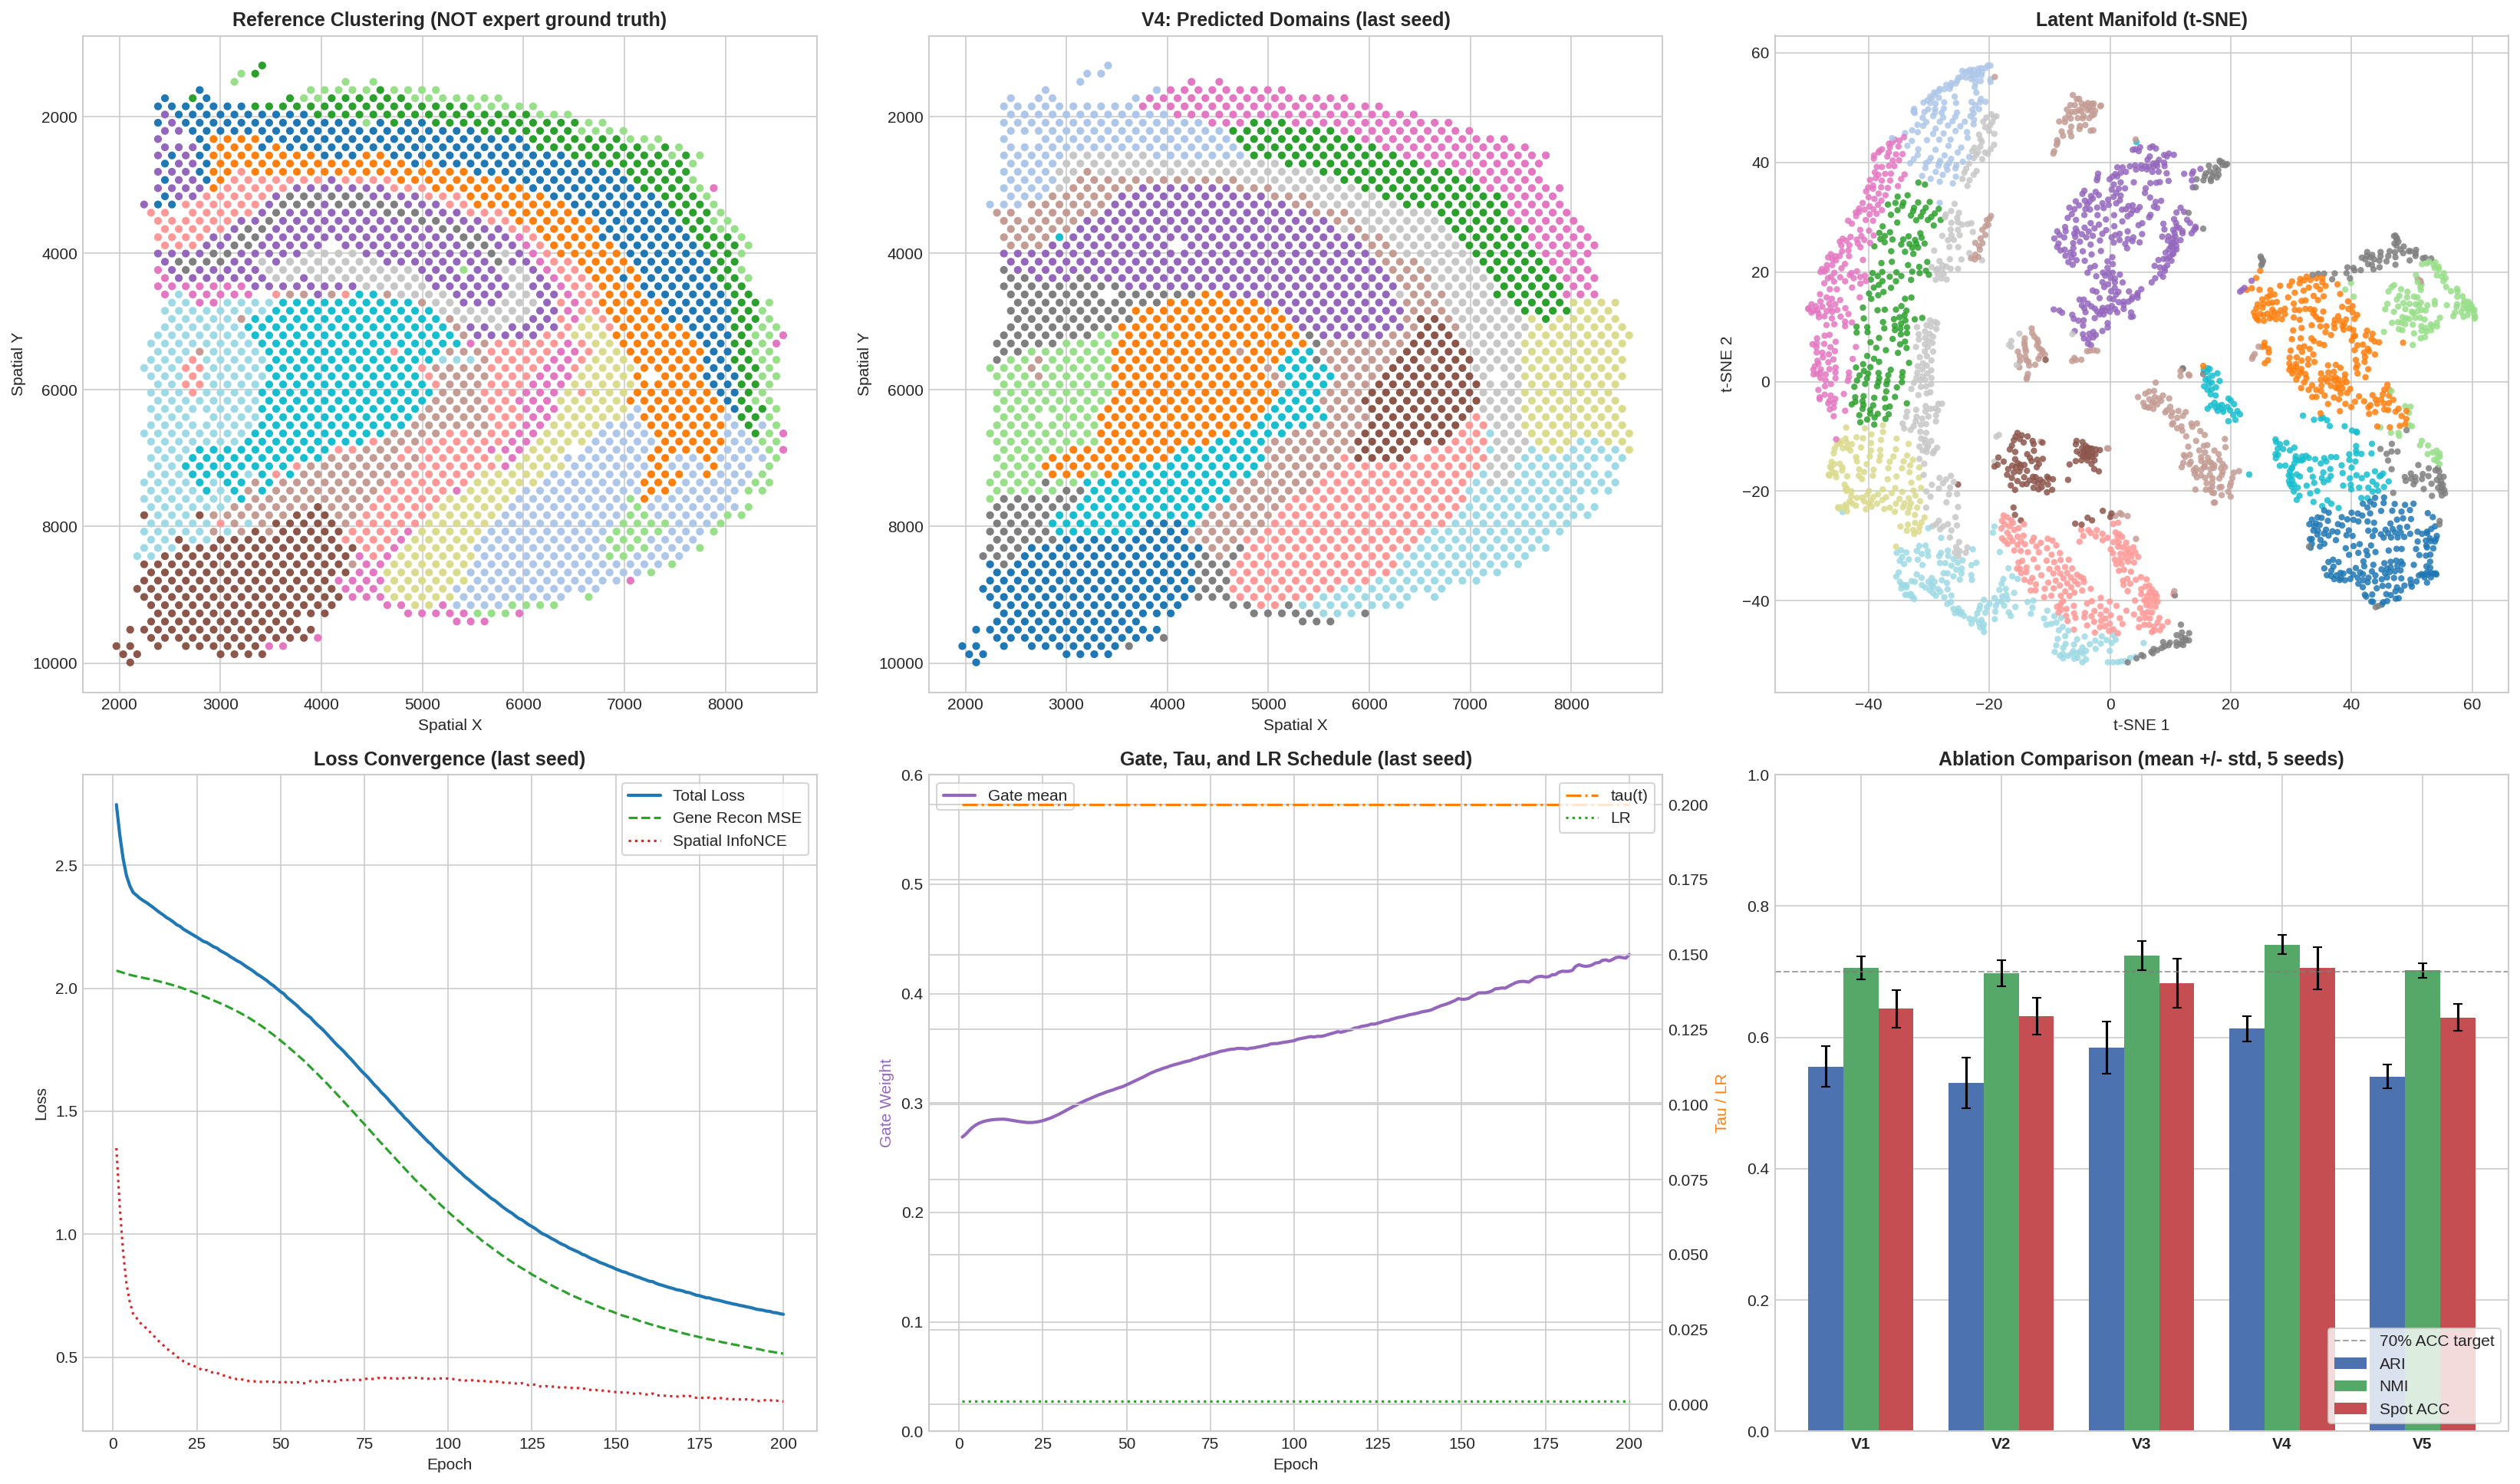

Figure saved to './output/benchmark_results.png'


In [15]:
print("Rendering diagnostic figures...")

tsne = TSNE(n_components=2, perplexity=30, random_state=BASE_SEED)
emb_2d = tsne.fit_transform(best_emb)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 3, figsize=(22, 13), dpi=150)

coords_spatial = adata.obsm["spatial"]

# [0,0] Reference clustering
ref_codes = pd.Series(ref_labels).astype('category').cat.codes.values
axes[0, 0].scatter(coords_spatial[:, 0], coords_spatial[:, 1], c=ref_codes, cmap="tab20", s=24, edgecolors='none')
axes[0, 0].set_title("Reference Clustering (NOT expert ground truth)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Spatial X")
axes[0, 0].set_ylabel("Spatial Y")
axes[0, 0].invert_yaxis()

# [0,1] Predicted domains (best variant, last seed)
axes[0, 1].scatter(coords_spatial[:, 0], coords_spatial[:, 1], c=best_pred, cmap="tab20", s=24, edgecolors='none')
axes[0, 1].set_title(f"{best_key}: Predicted Domains (last seed)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Spatial X")
axes[0, 1].set_ylabel("Spatial Y")
axes[0, 1].invert_yaxis()

# [0,2] t-SNE
axes[0, 2].scatter(emb_2d[:, 0], emb_2d[:, 1], c=best_pred, cmap="tab20", s=16, alpha=0.85, edgecolors='none')
axes[0, 2].set_title("Latent Manifold (t-SNE)", fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel("t-SNE 1")
axes[0, 2].set_ylabel("t-SNE 2")

# [1,0] Loss convergence (best variant, last seed)
hist = training_histories[best_key]
ep = np.arange(1, len(hist["total_loss"]) + 1)
axes[1, 0].plot(ep, hist["total_loss"], label="Total Loss", color="#1f77b4", lw=2)
axes[1, 0].plot(ep, hist["recon_gene"], label="Gene Recon MSE", color="#2ca02c", lw=1.5, ls="--")
axes[1, 0].plot(ep, hist["contrast_loss"], label="Spatial InfoNCE", color="#d62728", lw=1.5, ls=":")
axes[1, 0].set_title("Loss Convergence (last seed)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend(frameon=True)

# [1,1] Gate trajectory + tau + LR
ax11 = axes[1, 1]
ax11.plot(ep, hist["gate_mean"], color="#9467bd", lw=2, label="Gate mean")
ax11.set_xlabel("Epoch")
ax11.set_ylabel("Gate Weight", color="#9467bd")
ax11.set_ylim(0.0, 0.6)

ax11_tw = ax11.twinx()
ax11_tw.plot(ep, hist["tau"], color="#ff7f0e", lw=1.5, ls="-.", label="tau(t)")
ax11_tw.plot(ep, hist["lr"], color="#2ca02c", lw=1.5, ls=":", label="LR")
ax11_tw.set_ylabel("Tau / LR", color="#ff7f0e")
ax11.set_title("Gate, Tau, and LR Schedule (last seed)", fontsize=12, fontweight='bold')
ax11.legend(loc="upper left", frameon=True)
ax11_tw.legend(loc="upper right", frameon=True)

# [1,2] Ablation bar chart with error bars
variant_labels = [n.split(":")[0].replace("Variant ", "") for n, *_ in experiments]
means_ari, stds_ari = [], []
means_nmi, stds_nmi = [], []
means_acc, stds_acc = [], []
for name, *_ in experiments:
    df = pd.DataFrame(seed_results[name])
    means_ari.append(df.ARI.mean()); stds_ari.append(df.ARI.std())
    means_nmi.append(df.NMI.mean()); stds_nmi.append(df.NMI.std())
    means_acc.append(df.ACC.mean()); stds_acc.append(df.ACC.std())

x = np.arange(len(variant_labels))
w = 0.25
axes[1, 2].bar(x - w, means_ari, w, yerr=stds_ari, label="ARI", color="#4c72b0", capsize=3)
axes[1, 2].bar(x, means_nmi, w, yerr=stds_nmi, label="NMI", color="#55a868", capsize=3)
axes[1, 2].bar(x + w, means_acc, w, yerr=stds_acc, label="Spot ACC", color="#c44e52", capsize=3)
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(variant_labels, rotation=0, ha="center", fontsize=10, fontweight='bold')
axes[1, 2].set_ylim(0, 1.0)
axes[1, 2].axhline(y=0.70, color='gray', ls='--', lw=1, alpha=0.7, label='70% ACC target')
axes[1, 2].set_title(f"Ablation Comparison (mean +/- std, {N_SEEDS} seeds)", fontsize=12, fontweight='bold')
axes[1, 2].legend(loc="lower right", frameon=True)

plt.tight_layout()
fig_path = os.path.join(OUT_DIR, "benchmark_results.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to '{fig_path}'")

## Step 9: Silhouette Distribution

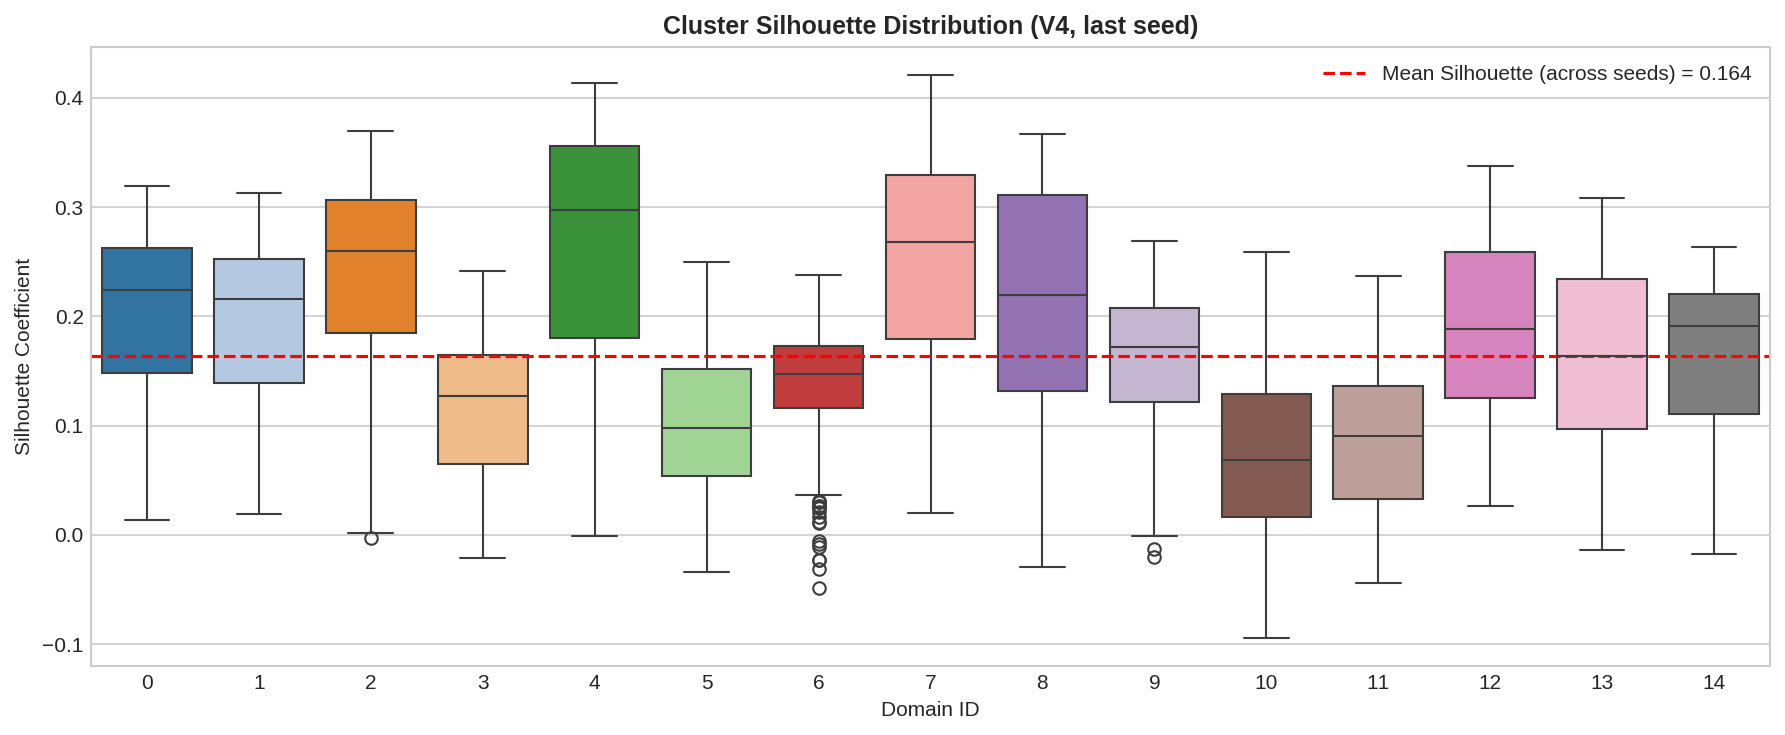

Silhouette figure saved to './output/silhouette_distribution.png'


In [16]:
sil_samples = silhouette_samples(best_emb, best_pred)
plt.figure(figsize=(12, 5), dpi=150)
sns.boxplot(x=best_pred, y=sil_samples, palette="tab20")

mean_sil = pd.DataFrame(seed_results[best_variant]).Sil.mean()
plt.axhline(y=mean_sil, color="red", ls="--", label=f"Mean Silhouette (across seeds) = {mean_sil:.3f}")
plt.title(f"Cluster Silhouette Distribution ({best_key}, last seed)", fontsize=12, fontweight='bold')
plt.xlabel("Domain ID")
plt.ylabel("Silhouette Coefficient")
plt.legend()
plt.tight_layout()

sil_path = os.path.join(OUT_DIR, "silhouette_distribution.png")
plt.savefig(sil_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Silhouette figure saved to '{sil_path}'")

## Step 10: Marker Gene Validation

Wilcoxon rank-sum differential expression on predicted domains.
`use_raw=False` passed explicitly so scanpy uses the log-normalized `.X` directly.

In [17]:
print("Extracting top marker genes per spatial domain (Wilcoxon rank-sum)...")
adata.obs["Spatial_Domain"] = pd.Categorical(best_pred.astype(str))

sc.tl.rank_genes_groups(
    adata, groupby="Spatial_Domain", method="wilcoxon", n_genes=10, use_raw=False
)

marker_df = pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(5)

try:
    marker_df.to_csv(os.path.join(OUT_DIR, "top_marker_genes_per_cluster.csv"), index=False)
    print(f"Marker genes saved to '{OUT_DIR}/top_marker_genes_per_cluster.csv'")
except Exception as e:
    print(f"Warning saving marker genes: {e}")

print("\nTop 5 marker genes per spatial domain (predicted, last seed of best variant):")
try:
    display(marker_df)
except NameError:
    print(marker_df)

Extracting top marker genes per spatial domain (Wilcoxon rank-sum)...
Marker genes saved to './output/top_marker_genes_per_cluster.csv'

Top 5 marker genes per spatial domain (predicted, last seed of best variant):


,0,1,10,11,12,13,14,2,3,4,5,6,7,8,9
0,Resp18,1110008P14Rik,Calb2,3110035E14Rik,Nptxr,Vamp1,Nptxr,Prkcd,Mef2c,Cbln1,Hpcal1,Hpca,Ppp1r1b,Cldn11,Lamp5
1,6330403K07Rik,Dkk3,Agt,Tbr1,Mef2c,Hcn2,Olfm1,Pcp4,Stx1a,Cbln4,Lypd1,Cnih2,Ttr,Mal,Atp1a1
2,Gpx3,Lmo4,Sparc,Ttc9b,Nov,Qdpr,Ttc9b,Rora,Satb1,Ctxn3,Nr2f2,Cabp7,Penk,Cnp,Mef2c
3,Ndn,Cplx1,Dbi,Ipcef1,Snca,Mobp,Slc30a3,Adarb1,Dkkl1,Tcf7l2,Hap1,Ncdn,Adora2a,Cryab,Camk2n1
4,Baiap3,Scn1b,Nnat,Trbc2,Stx1a,Rnd2,Slc17a7,Tnnt1,Cabp1,Foxp2,Ly6h,Psd,Gpr88,Mobp,Nrgn


## Step 11: Summary and Caveats

In [18]:
print("Generated artifacts:")
for fname in sorted(os.listdir(OUT_DIR)):
    fpath = os.path.join(OUT_DIR, fname)
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname:40s} ({size_kb:.1f} KB)")

print("\nCaveats:")
print(f"  1. Reference labels are squidpy's Leiden clustering, not expert-annotated anatomy.")
print(f"  2. No comparison to published baselines (STAGATE, GraphST, conST, SpaGCN, DeepST).")
print(f"  3. N_SEEDS={N_SEEDS} seeds used. Increase for narrower confidence intervals.")
print(f"  4. The 0.70/0.30 multi-scale weighting is a heuristic, not a tuned hyperparameter.")
print(f"  5. KMeans uses n_clusters={n_clusters} from reference labels (not discovered automatically).")
print("\nPipeline finished.")

Generated artifacts:
  ablation_per_seed_raw.csv                (3.0 KB)
  ablation_study_table.csv                 (0.7 KB)
  benchmark_results.png                    (1435.8 KB)
  domain_predictions.csv                   (86.4 KB)
  silhouette_distribution.png              (56.5 KB)
  spatial_gnn_embeddings.csv               (4287.7 KB)
  top_marker_genes_per_cluster.csv         (0.5 KB)

Caveats:
  1. Reference labels are squidpy's Leiden clustering, not expert-annotated anatomy.
  2. No comparison to published baselines (STAGATE, GraphST, conST, SpaGCN, DeepST).
  3. N_SEEDS=5 seeds used. Increase for narrower confidence intervals.
  4. The 0.70/0.30 multi-scale weighting is a heuristic, not a tuned hyperparameter.
  5. KMeans uses n_clusters=15 from reference labels (not discovered automatically).

Pipeline finished.
